# Notebook 5 - Analisis de Negocio

Este cuaderno desarrolla la fase de Analisis de Negocio a partir de la base municipal segmentada generada en el `Notebook 4`.

A diferencia de los cuadernos anteriores, aqui el objetivo principal no es construir ni validar el dato, sino traducir los resultados tecnicos a una lectura aplicada para el sector asegurador. En este contexto, se interpretan los clusters, los indicadores de peligro climatico, la vulnerabilidad territorial y la exposicion fisica derivada de Catastro con el fin de identificar perfiles municipales relevantes, prioridades de actuacion y posibles implicaciones para tarificacion, prevencion y gestion de cartera.

La segmentacion principal utilizada para negocio es la obtenida con `KMeans`. Los resultados de `Agglomerative Clustering` y `DBSCAN` se conservan como contrastes metodologicos: el primero ayuda a comprobar estabilidad y el segundo aporta una lectura auxiliar de densidad espacial y municipios singulares, pero no se utiliza como segmentacion operativa principal.

La entrada principal del notebook es:

`DATA/PROCESSED/dataset_cv_municipios_segmentado.csv`

## 0. Configuracion inicial

En este bloque se cargan las librerias necesarias y se definen las rutas de trabajo. El notebook parte de la base municipal ya enriquecida y segmentada, por lo que no repite ni el proceso ETL ni el modelado previo.

Ademas, se preparan las rutas para posibles salidas de tablas, mapas y materiales de apoyo orientados a la interpretacion de negocio.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
MAPS = OUT / "maps"
BUSINESS_OUT = OUT / "negocio"

SEGMENTED_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_segmentado.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"

MAPS.mkdir(parents=True, exist_ok=True)
BUSINESS_OUT.mkdir(parents=True, exist_ok=True)

print("Base municipal segmentada:", SEGMENTED_MUNICIPAL_FILE)
print("Existe:", SEGMENTED_MUNICIPAL_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())
print("Directorio de salida negocio:", BUSINESS_OUT)

Base municipal segmentada: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv
Existe: True
Geometria municipal disponible: True
Directorio de salida negocio: C:\Users\gonza\OneDrive\tfg\output\negocio


## 1. Objetivo de negocio y carga de la base segmentada

El objetivo de esta fase es interpretar la informacion municipal generada en los cuadernos anteriores desde una perspectiva aplicada al negocio asegurador. Para ello, se parte de los clusters, de los indicadores climaticos, de las variables territoriales y de la exposicion edificada ya construidas, y se analizan en terminos de peligro, vulnerabilidad, exposicion y prioridad operativa.

Dado que no se dispone de datos reales de siniestralidad, esta lectura no pretende sustituir un modelo actuarial ni una tarificacion real, sino ofrecer una aproximacion exploratoria que ayude a identificar perfiles municipales de interes, zonas de vigilancia prioritaria y posibles lineas de continuidad para una aseguradora.

`DBSCAN` aparece en esta fase como comprobacion de coherencia con el modelado anterior. Su utilidad de negocio es senalar agrupaciones densas o municipios singulares, pero las etiquetas de perfil y las prioridades operativas se construyen sobre `KMeans`, por ser la solucion mas equilibrada e interpretable.

In [2]:
df_seg = pd.read_csv(SEGMENTED_MUNICIPAL_FILE)

riesgo_col = "score_riesgo_exploratorio"
peligro_col = "score_peligro_climatico_ampliado"
vulnerabilidad_col = "score_vulnerabilidad"
exposicion_col = "score_exposicion_fisica"

required_cols = [
    "municipio", "CODNUT2", "CODNUT3", "cluster_kmeans", "cluster_agg", "cluster_dbscan",
    riesgo_col, peligro_col, vulnerabilidad_col, exposicion_col,
]
missing_required = [col for col in required_cols if col not in df_seg.columns]
if missing_required:
    raise ValueError(f"Faltan columnas necesarias para el analisis de negocio: {missing_required}")

print("Shape:", df_seg.shape)
print("Municipios unicos:", df_seg["municipio"].nunique())
print("Duplicados municipales:", df_seg.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())
print("Clusters KMeans disponibles:", sorted(df_seg["cluster_kmeans"].dropna().unique().tolist()))
print("Clusters Agglomerative disponibles:", sorted(df_seg["cluster_agg"].dropna().unique().tolist()))
print("Etiquetas DBSCAN disponibles:", sorted(df_seg["cluster_dbscan"].dropna().unique().tolist()))
print("Municipios marcados como ruido por DBSCAN:", int((df_seg["cluster_dbscan"] == -1).sum()))

assert df_seg["municipio"].nunique() == 542, "La base segmentada debe conservar 542 municipios."
assert df_seg.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum() == 0, "Hay duplicados municipales."
assert df_seg["cluster_kmeans"].nunique() == 4, "El analisis de negocio espera la solucion KMeans final de 4 clusters."
assert df_seg["cluster_dbscan"].isna().sum() == 0, "Hay municipios sin etiqueta DBSCAN."

business_cols = [
    "municipio",
    "cluster_kmeans",
    "cluster_dbscan",
    riesgo_col,
    peligro_col,
    vulnerabilidad_col,
    exposicion_col,
    "precip_p99",
    "dias_calor_intenso",
    "dias_suelo_seco",
    "densidad_poblacion",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
    "altitud_m",
]

business_cols = [col for col in business_cols if col in df_seg.columns]
display(df_seg[business_cols].head())

Shape: (542, 85)
Municipios unicos: 542
Duplicados municipales: 0
Clusters KMeans disponibles: [0, 1, 2, 3]
Clusters Agglomerative disponibles: [0, 1, 2, 3]
Etiquetas DBSCAN disponibles: [-1, 0, 1, 2, 3]
Municipios marcados como ruido por DBSCAN: 50


,municipio,cluster_kmeans,cluster_dbscan,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,precip_p99,dias_calor_intenso,dias_suelo_seco,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
0,Ademuz,0,-1,0.244267,0.229361,0.430498,0.002188,18.368174,60,0,10.12,14.38,0.1728,907.0
1,Ador,2,0,0.366637,0.519953,0.348130,0.011108,37.833611,68,537,126.84,70.97,1.0499,79.0
2,Agost,1,0,0.302003,0.387744,0.355532,0.007359,18.520694,97,1505,78.39,43.79,0.8237,181.0
3,Agres,2,0,0.311068,0.389693,0.384731,0.004014,31.017301,176,0,24.10,23.64,0.4122,756.0
4,Agullent,2,0,0.313503,0.402116,0.360871,0.020919,28.305807,200,84,150.09,72.46,2.7882,556.0


### 1.1 Papel de cada enfoque de modelado en negocio

Antes de interpretar perfiles y prioridades, se deja fijado que papel tiene cada algoritmo en esta fase. Esto evita mezclar una segmentacion operativa con pruebas de contraste metodologico.

In [3]:
modeling_role_table = pd.DataFrame(
    [
        {
            "enfoque": "KMeans",
            "papel_en_negocio": "Segmentacion principal",
            "motivo": "Solucion equilibrada, estable e interpretable para definir perfiles municipales.",
        },
        {
            "enfoque": "Agglomerative Clustering",
            "papel_en_negocio": "Contraste metodologico",
            "motivo": "Permite comprobar si la estructura territorial se mantiene con otro algoritmo.",
        },
        {
            "enfoque": "DBSCAN",
            "papel_en_negocio": "Lectura auxiliar de densidad",
            "motivo": "Ayuda a detectar agrupaciones densas y municipios singulares, pero no sustituye a KMeans.",
        },
    ]
)

display(modeling_role_table)

dbscan_business_reading = (
    df_seg.assign(es_ruido_dbscan=df_seg["cluster_dbscan"].eq(-1))
    .groupby("cluster_dbscan")
    .agg(
        municipios=("municipio", "count"),
        riesgo_exploratorio=(riesgo_col, "mean"),
        peligro_climatico_ampliado=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_fisica_media=(exposicion_col, "mean"),
        ruido_dbscan=("es_ruido_dbscan", "max"),
    )
    .round(3)
)

display(dbscan_business_reading)

,enfoque,papel_en_negocio,motivo
0,KMeans,Segmentacion principal,"Solucion equilibrada, estable e interpretable ..."
1,Agglomerative Clustering,Contraste metodologico,Permite comprobar si la estructura territorial...
2,DBSCAN,Lectura auxiliar de densidad,Ayuda a detectar agrupaciones densas y municip...


,municipios,riesgo_exploratorio,peligro_climatico_ampliado,vulnerabilidad_media,exposicion_fisica_media,ruido_dbscan
cluster_dbscan,,,,,,
-1,50,0.331,0.347,0.470,0.082,True
0,271,0.332,0.422,0.386,0.026,False
1,176,0.260,0.286,0.368,0.031,False
2,39,0.310,0.361,0.428,0.004,False
3,6,0.246,0.259,0.377,0.017,False


## 2. Lectura de clusters en clave negocio

El primer paso del Analisis de Negocio consiste en traducir la segmentacion obtenida con `KMeans` a perfiles municipales interpretables desde una perspectiva aseguradora. Para ello, se comparan los clusters en terminos de peligro climatico, vulnerabilidad territorial, exposicion y contexto socioeconomico.

El objetivo no es asignar todavia decisiones tarifarias cerradas, sino identificar tipologias territoriales con implicaciones potenciales para prevencion, vigilancia, segmentacion comercial o priorizacion analitica.

La lectura de negocio se centra en `KMeans` porque fue el modelo seleccionado como salida principal del `Notebook 4`. `Agglomerative Clustering` y `DBSCAN` no se descartan, pero se interpretan como evidencias auxiliares: ayudan a comprobar estabilidad y densidad espacial, mientras que los perfiles de negocio se asignan sobre una solucion de clusters mas clara y accionable.

In [4]:
cluster_business_summary = (
    df_seg.groupby("cluster_kmeans")
    .agg(
        municipios=("municipio", "count"),
        riesgo_exploratorio=(riesgo_col, "mean"),
        peligro_climatico_ampliado=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_fisica_media=(exposicion_col, "mean"),
        precip_p99=("precip_p99", "mean"),
        dias_calor_intenso=("dias_calor_intenso", "mean"),
        viento_p95=("viento_p95", "mean"),
        dias_suelo_seco=("dias_suelo_seco", "mean"),
        dias_radiacion_alta=("dias_radiacion_alta", "mean"),
        dias_runoff_extremo=("dias_runoff_extremo", "mean"),
        densidad_poblacion=("densidad_poblacion", "mean"),
        mayores_65_pct=("mayores_65_pct", "mean"),
        renta_media_hogar=("renta_media_hogar", "mean"),
        densidad_viviendas_catastro_km2=("densidad_viviendas_catastro_km2", "mean"),
        ratio_huella_edificada_pct=("ratio_huella_edificada_pct", "mean"),
        altitud_m=("altitud_m", "mean"),
    )
    .round(3)
    .sort_values("riesgo_exploratorio", ascending=False)
)

display(cluster_business_summary)

,municipios,riesgo_exploratorio,peligro_climatico_ampliado,vulnerabilidad_media,exposicion_fisica_media,precip_p99,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,,
2,136,0.333,0.438,0.367,0.016,31.470,166.949,6.540,146.757,231.404,122.596,167.110,23.186,32162.731,94.254,1.735,306.904
1,68,0.320,0.395,0.392,0.027,19.354,182.794,7.021,654.426,278.941,60.603,431.051,23.328,29664.176,248.872,2.589,329.632
3,128,0.302,0.362,0.340,0.095,27.172,82.023,7.499,133.820,202.562,114.055,2007.795,19.826,35138.906,1022.443,8.658,76.859
0,210,0.286,0.310,0.436,0.004,26.290,65.581,6.916,177.229,202.110,114.348,25.498,29.623,30111.108,23.490,0.361,640.438


In [5]:
cluster_business_labels = {
    0: "Interior envejecido y baja exposicion construida",
    1: "Calor y sequedad elevados con vulnerabilidad media",
    2: "Peligro climatico alto con exposicion moderada",
    3: "Exposicion urbana alta y baja altitud",
}

df_seg["perfil_negocio_kmeans"] = df_seg["cluster_kmeans"].map(cluster_business_labels)

if df_seg["perfil_negocio_kmeans"].isna().any():
    missing_clusters = sorted(df_seg.loc[df_seg["perfil_negocio_kmeans"].isna(), "cluster_kmeans"].unique().tolist())
    raise ValueError(f"Faltan etiquetas de negocio para clusters: {missing_clusters}")

cluster_label_table = (
    df_seg[["cluster_kmeans", "perfil_negocio_kmeans"]]
    .drop_duplicates()
    .sort_values("cluster_kmeans")
)

display(cluster_label_table)

,cluster_kmeans,perfil_negocio_kmeans
0,0,Interior envejecido y baja exposicion construida
2,1,Calor y sequedad elevados con vulnerabilidad m...
1,2,Peligro climatico alto con exposicion moderada
9,3,Exposicion urbana alta y baja altitud


In [6]:
municipios_representativos = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_col,
        ]
    ]
    .sort_values(["cluster_kmeans", riesgo_col], ascending=[True, False])
    .groupby("cluster_kmeans")
    .head(5)
)

display(municipios_representativos)

,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica
21,Alcalalí,0,Interior envejecido y baja exposicion construida,0.404743,0.474477,0.550479,0.011805
485,Zarra,0,Interior envejecido y baja exposicion construida,0.391445,0.429470,0.588241,0.001189
119,Benimeli,0,Interior envejecido y baja exposicion construida,0.384415,0.474477,0.481483,0.013659
345,Pinet,0,Interior envejecido y baja exposicion construida,0.381807,0.500837,0.436184,0.002665
131,Bicorp,0,Interior envejecido y baja exposicion construida,0.380329,0.453082,0.512421,0.000307
456,Venta del Moro,1,Calor y sequedad elevados con vulnerabilidad m...,0.395733,0.463267,0.546350,0.000975
384,San Fulgencio,1,Calor y sequedad elevados con vulnerabilidad m...,0.393870,0.399722,0.605117,0.062369
256,Hondón de los Frailes,1,Calor y sequedad elevados con vulnerabilidad m...,0.392957,0.425387,0.591417,0.014191
372,Rojales,1,Calor y sequedad elevados con vulnerabilidad m...,0.376697,0.399722,0.548013,0.062162
468,Villargordo del Cabriel,1,Calor y sequedad elevados con vulnerabilidad m...,0.372429,0.463267,0.468121,0.001796


La comparacion entre clusters permite construir una primera tipologia territorial util para negocio. En los resultados actuales, el cluster `2` destaca por mayor peligro climatico medio, con valores altos en precipitacion extrema y calor. El cluster `1` concentra un perfil de calor y sequedad elevados, con una vulnerabilidad media y una exposicion fisica moderada.

El cluster `3` tiene una lectura distinta: no es el grupo con mayor vulnerabilidad social, pero si concentra la mayor exposicion urbana y construida, con densidades de poblacion y vivienda muy superiores y menor altitud media. Por ultimo, el cluster `0` agrupa muchos municipios interiores, de baja exposicion construida, mayor altitud y envejecimiento demografico mas marcado.

Desde la perspectiva aseguradora, esta tipologia no equivale todavia a una politica de tarificacion, pero si resulta util para priorizar analisis posteriores, vigilancia territorial y posibles estrategias diferenciadas de prevencion o seguimiento de cartera.

## 3. Priorizacion municipal y ranking operativo

Una vez interpretados los clusters, el siguiente paso consiste en priorizar municipios desde una perspectiva operativa. Esta priorizacion no debe entenderse como una decision tarifaria automatica, sino como una herramienta exploratoria para identificar territorios que merecen mayor seguimiento, analisis adicional o atencion preventiva.

Para ello, se revisan cuatro lecturas complementarias: el score de riesgo exploratorio, el peligro climatico ampliado, la vulnerabilidad territorial y la exposicion fisica. De este modo, es posible distinguir municipios que destacan por intensidad climatica, fragilidad social, concentracion edificada o por la combinacion de varias dimensiones.

In [7]:
ranking_cols = [
    "municipio",
    "cluster_kmeans",
    "perfil_negocio_kmeans",
    riesgo_col,
    peligro_col,
    vulnerabilidad_col,
    exposicion_col,
    "densidad_poblacion",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
    "mayores_65_pct",
    "renta_media_hogar",
]
ranking_cols = [col for col in ranking_cols if col in df_seg.columns]

ranking_riesgo = df_seg[ranking_cols].sort_values(riesgo_col, ascending=False).head(10)
ranking_peligro = df_seg[ranking_cols].sort_values(peligro_col, ascending=False).head(10)
ranking_vulnerabilidad = df_seg[ranking_cols].sort_values(vulnerabilidad_col, ascending=False).head(10)
ranking_exposicion = df_seg[ranking_cols].sort_values(exposicion_col, ascending=False).head(10)

print("Top 10 municipios por score de riesgo exploratorio")
display(ranking_riesgo)
print("Top 10 municipios por peligro climatico ampliado")
display(ranking_peligro)
print("Top 10 municipios por vulnerabilidad territorial")
display(ranking_vulnerabilidad)
print("Top 10 municipios por exposicion fisica")
display(ranking_exposicion)

Top 10 municipios por score de riesgo exploratorio


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
92,Benetússer,3,Exposicion urbana alta y baja altitud,0.490856,0.347842,0.625274,0.646767,21451.10,9253.94,51.6428,19.36,32367.0
215,Emperador,3,Exposicion urbana alta y baja altitud,0.487039,0.345037,0.550293,0.747165,24305.56,10763.89,53.6153,12.15,39021.0
267,Llocnou de la Corona,3,Exposicion urbana alta y baja altitud,0.469190,0.347842,0.438218,0.819019,10476.19,4920.63,64.6723,16.42,33832.0
290,Mislata,3,Exposicion urbana alta y baja altitud,0.456715,0.327184,0.635632,0.512166,23121.01,9949.91,30.7877,20.43,35060.0
507,l'Atzúbia,2,Peligro climatico alto con exposicion moderada,0.406311,0.519953,0.483333,0.006673,40.12,40.40,0.5672,35.94,30891.0
21,Alcalalí,0,Interior envejecido y baja exposicion construida,0.404743,0.474477,0.550479,0.011805,99.19,73.77,1.0291,40.85,27781.0
500,els Poblets,3,Exposicion urbana alta y baja altitud,0.404010,0.474477,0.484944,0.106444,748.17,775.03,8.7663,35.28,31207.0
100,Benicolet,2,Peligro climatico alto con exposicion moderada,0.401123,0.523869,0.459171,0.007183,53.82,34.68,0.7769,31.98,29760.0
80,Bellreguard,3,Exposicion urbana alta y baja altitud,0.396461,0.519953,0.356009,0.148411,1770.21,1556.32,12.5672,19.01,31917.0
456,Venta del Moro,1,Calor y sequedad elevados con vulnerabilidad m...,0.395733,0.463267,0.546350,0.000975,4.20,5.65,0.1245,35.93,22952.0


Top 10 municipios por peligro climatico ampliado


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
270,Llutxent,2,Peligro climatico alto con exposicion moderada,0.372782,0.523869,0.365447,0.006066,57.67,30.16,0.6687,22.06,31019.0
49,Almiserà,2,Peligro climatico alto con exposicion moderada,0.379626,0.523869,0.389528,0.004164,37.22,24.63,0.3565,25.71,31822.0
298,Montitxelvo/Montichelvo,2,Peligro climatico alto con exposicion moderada,0.375639,0.523869,0.373657,0.008038,67.42,42.93,0.7560,24.60,32686.0
266,Llocnou de Sant Jeroni,2,Peligro climatico alto con exposicion moderada,0.375329,0.523869,0.369396,0.012875,91.80,53.93,1.5196,25.34,34039.0
6,Aielo de Rugat,2,Peligro climatico alto con exposicion moderada,0.375265,0.523869,0.375442,0.003487,20.71,16.05,0.3573,35.40,43758.0
100,Benicolet,2,Peligro climatico alto con exposicion moderada,0.401123,0.523869,0.459171,0.007183,53.82,34.68,0.7769,31.98,29760.0
424,Terrateig,2,Peligro climatico alto con exposicion moderada,0.382439,0.523869,0.395329,0.009527,46.17,33.12,1.2457,27.53,33030.0
166,Castellonet de la Conquesta,2,Peligro climatico alto con exposicion moderada,0.350835,0.523869,0.294397,0.002906,29.19,15.42,0.3030,24.05,41936.0
377,Ròtova,2,Peligro climatico alto con exposicion moderada,0.381662,0.523869,0.388296,0.016192,167.52,102.23,1.6506,27.29,33863.0
78,Barxeta,2,Peligro climatico alto con exposicion moderada,0.378217,0.523390,0.383960,0.006671,55.31,35.54,0.6803,25.84,32685.0


Top 10 municipios por vulnerabilidad territorial


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
290,Mislata,3,Exposicion urbana alta y baja altitud,0.456715,0.327184,0.635632,0.512166,23121.01,9949.91,30.7877,20.43,35060.0
92,Benetússer,3,Exposicion urbana alta y baja altitud,0.490856,0.347842,0.625274,0.646767,21451.10,9253.94,51.6428,19.36,32367.0
83,Benafigos,0,Interior envejecido y baja exposicion construida,0.327297,0.285100,0.614640,0.001772,3.40,8.06,0.1392,45.45,24452.0
384,San Fulgencio,1,Calor y sequedad elevados con vulnerabilidad m...,0.393870,0.399722,0.605117,0.062369,471.80,504.89,4.6938,42.84,23694.0
304,Murla,0,Interior envejecido y baja exposicion construida,0.378256,0.393853,0.595239,0.013787,98.66,75.28,1.2620,44.77,26321.0
423,Teresa de Cofrentes,0,Interior envejecido y baja exposicion construida,0.376607,0.396922,0.593221,0.000899,5.60,5.80,0.1107,43.20,24760.0
256,Hondón de los Frailes,1,Calor y sequedad elevados con vulnerabilidad m...,0.392957,0.425387,0.591417,0.014191,106.33,83.85,1.3580,40.67,22493.0
485,Zarra,0,Interior envejecido y baja exposicion construida,0.391445,0.429470,0.588241,0.001189,7.52,6.20,0.1495,42.26,24395.0
358,Quatretondeta,0,Interior envejecido y baja exposicion construida,0.314788,0.277435,0.586031,0.001306,7.78,8.44,0.1465,39.53,21796.0
222,Famorca,0,Interior envejecido y baja exposicion construida,0.312046,0.276803,0.578180,0.000955,4.52,8.12,0.0922,47.73,NaN


Top 10 municipios por exposicion fisica


,municipio,cluster_kmeans,perfil_negocio_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
267,Llocnou de la Corona,3,Exposicion urbana alta y baja altitud,0.469190,0.347842,0.438218,0.819019,10476.19,4920.63,64.6723,16.42,33832.0
215,Emperador,3,Exposicion urbana alta y baja altitud,0.487039,0.345037,0.550293,0.747165,24305.56,10763.89,53.6153,12.15,39021.0
92,Benetússer,3,Exposicion urbana alta y baja altitud,0.490856,0.347842,0.625274,0.646767,21451.10,9253.94,51.6428,19.36,32367.0
290,Mislata,3,Exposicion urbana alta y baja altitud,0.456715,0.327184,0.635632,0.512166,23121.01,9949.91,30.7877,20.43,35060.0
420,Tavernes Blanques,3,Exposicion urbana alta y baja altitud,0.391254,0.327184,0.498794,0.390122,12543.41,5517.11,32.9321,20.42,34022.0
141,Burjassot,3,Exposicion urbana alta y baja altitud,0.383491,0.327184,0.488539,0.366685,11941.99,5142.99,28.9143,18.40,32145.0
9,Alaquàs,3,Exposicion urbana alta y baja altitud,0.354262,0.313811,0.452375,0.308218,7813.20,3365.28,32.3449,21.15,32487.0
326,Paiporta,3,Exposicion urbana alta y baja altitud,0.332490,0.347842,0.371639,0.235388,7049.69,2981.13,21.2341,15.50,35308.0
398,Sedaví,3,Exposicion urbana alta y baja altitud,0.341962,0.347842,0.404787,0.233026,5938.41,2506.99,22.1092,21.02,35081.0
479,Xirivella,3,Exposicion urbana alta y baja altitud,0.325485,0.327184,0.414210,0.188152,6240.98,2617.31,16.7607,18.30,31558.0


In [8]:
priority_order = ["Muy alta", "Alta", "Media", "Baja"]

p90_riesgo = df_seg[riesgo_col].quantile(0.90)
p75_riesgo = df_seg[riesgo_col].quantile(0.75)
p50_riesgo = df_seg[riesgo_col].median()
p75_peligro = df_seg[peligro_col].quantile(0.75)
p75_vulnerabilidad = df_seg[vulnerabilidad_col].quantile(0.75)
p75_exposicion = df_seg[exposicion_col].quantile(0.75)

condiciones = [
    (df_seg[riesgo_col] >= p90_riesgo)
    | (
        (df_seg[peligro_col] >= p75_peligro)
        & (
            (df_seg[vulnerabilidad_col] >= p75_vulnerabilidad)
            | (df_seg[exposicion_col] >= p75_exposicion)
        )
    ),
    df_seg[riesgo_col] >= p75_riesgo,
    df_seg[riesgo_col] >= p50_riesgo,
]

etiquetas = ["Muy alta", "Alta", "Media"]

df_seg["prioridad_negocio"] = np.select(condiciones, etiquetas, default="Baja")
df_seg["prioridad_negocio"] = pd.Categorical(
    df_seg["prioridad_negocio"],
    categories=priority_order,
    ordered=True,
)

threshold_table = pd.DataFrame(
    {
        "umbral": ["p90_riesgo", "p75_riesgo", "p50_riesgo", "p75_peligro", "p75_vulnerabilidad", "p75_exposicion"],
        "valor": [p90_riesgo, p75_riesgo, p50_riesgo, p75_peligro, p75_vulnerabilidad, p75_exposicion],
    }
).round(3)

display(threshold_table)

priority_summary = (
    df_seg.groupby("prioridad_negocio", observed=False)
    .agg(
        municipios=("municipio", "count"),
        riesgo_medio=(riesgo_col, "mean"),
        peligro_medio=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_media=(exposicion_col, "mean"),
    )
    .round(3)
    .reindex(priority_order)
)

display(priority_summary)

,umbral,valor
0,p90_riesgo,0.371
1,p75_riesgo,0.342
2,p50_riesgo,0.304
3,p75_peligro,0.432
4,p75_vulnerabilidad,0.439
5,p75_exposicion,0.031


,municipios,riesgo_medio,peligro_medio,vulnerabilidad_media,exposicion_media
prioridad_negocio,,,,,
Muy alta,86,0.376,0.469,0.423,0.073
Alta,57,0.353,0.449,0.413,0.024
Media,128,0.322,0.396,0.400,0.022
Baja,271,0.266,0.299,0.371,0.024


In [9]:
municipios_prioritarios = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_col,
        ]
    ]
    .query("prioridad_negocio in ['Muy alta', 'Alta']")
    .sort_values(["prioridad_negocio", riesgo_col], ascending=[True, False])
)

display(municipios_prioritarios.head(20))

,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica
92,Benetússer,3,Exposicion urbana alta y baja altitud,Muy alta,0.490856,0.347842,0.625274,0.646767
215,Emperador,3,Exposicion urbana alta y baja altitud,Muy alta,0.487039,0.345037,0.550293,0.747165
267,Llocnou de la Corona,3,Exposicion urbana alta y baja altitud,Muy alta,0.469190,0.347842,0.438218,0.819019
290,Mislata,3,Exposicion urbana alta y baja altitud,Muy alta,0.456715,0.327184,0.635632,0.512166
507,l'Atzúbia,2,Peligro climatico alto con exposicion moderada,Muy alta,0.406311,0.519953,0.483333,0.006673
21,Alcalalí,0,Interior envejecido y baja exposicion construida,Muy alta,0.404743,0.474477,0.550479,0.011805
500,els Poblets,3,Exposicion urbana alta y baja altitud,Muy alta,0.404010,0.474477,0.484944,0.106444
100,Benicolet,2,Peligro climatico alto con exposicion moderada,Muy alta,0.401123,0.523869,0.459171,0.007183
80,Bellreguard,3,Exposicion urbana alta y baja altitud,Muy alta,0.396461,0.519953,0.356009,0.148411
456,Venta del Moro,1,Calor y sequedad elevados con vulnerabilidad m...,Muy alta,0.395733,0.463267,0.546350,0.000975


La priorizacion obtenida permite pasar de una lectura descriptiva de clusters a una primera propuesta de seguimiento operativo. Los municipios clasificados con prioridad `Muy alta` combinan valores muy elevados de riesgo exploratorio o cruces especialmente sensibles entre peligro climatico y vulnerabilidad o exposicion fisica.

Por su parte, las prioridades `Alta` y `Media` recogen perfiles donde una de las dimensiones destaca con fuerza, aunque la combinacion global sea menos extrema. Esta distincion resulta util porque evita tratar de forma identica municipios con riesgos de naturaleza distinta: algunos destacan por exposicion urbana, otros por envejecimiento y altitud, y otros por precipitacion extrema, calor, sequedad o viento.

Desde la perspectiva aseguradora, esta tipologia puede servir como base para ordenar territorios, focalizar estudios complementarios y plantear estrategias diferenciadas de prevencion, seguimiento o revision analitica de cartera.

## 4. Representacion espacial de prioridades y perfiles de negocio

La lectura de negocio gana fuerza cuando los perfiles y prioridades identificados se trasladan al espacio geografico. En este bloque se representan los clusters principales, la prioridad operativa y el score de riesgo exploratorio para comprobar si existen concentraciones territoriales, continuidades espaciales o contrastes relevantes entre zonas.

El objetivo no es producir una zonificacion definitiva del riesgo asegurador, sino aportar una evidencia visual que ayude a interpretar mejor donde se concentran los perfiles municipales mas sensibles desde la perspectiva del negocio.

In [10]:
gdf_business = gpd.read_file(MUNICIPIOS_GEO_FILE).merge(
    df_seg[
        [
            "municipio",
            "CODNUT2",
            "CODNUT3",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_col,
        ]
    ],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_business))
print("Municipios con prioridad asignada:", gdf_business["prioridad_negocio"].notna().sum())
display(gdf_business[["municipio", "cluster_kmeans", "prioridad_negocio", riesgo_col]].head())

Municipios en geometria: 542
Municipios con prioridad asignada: 542


,municipio,cluster_kmeans,prioridad_negocio,score_riesgo_exploratorio
0,l'Atzúbia,2,Muy alta,0.406311
1,Agost,1,Baja,0.302003
2,Agres,2,Media,0.311068
3,Aigües,1,Baja,0.272615
4,Albatera,1,Baja,0.289251


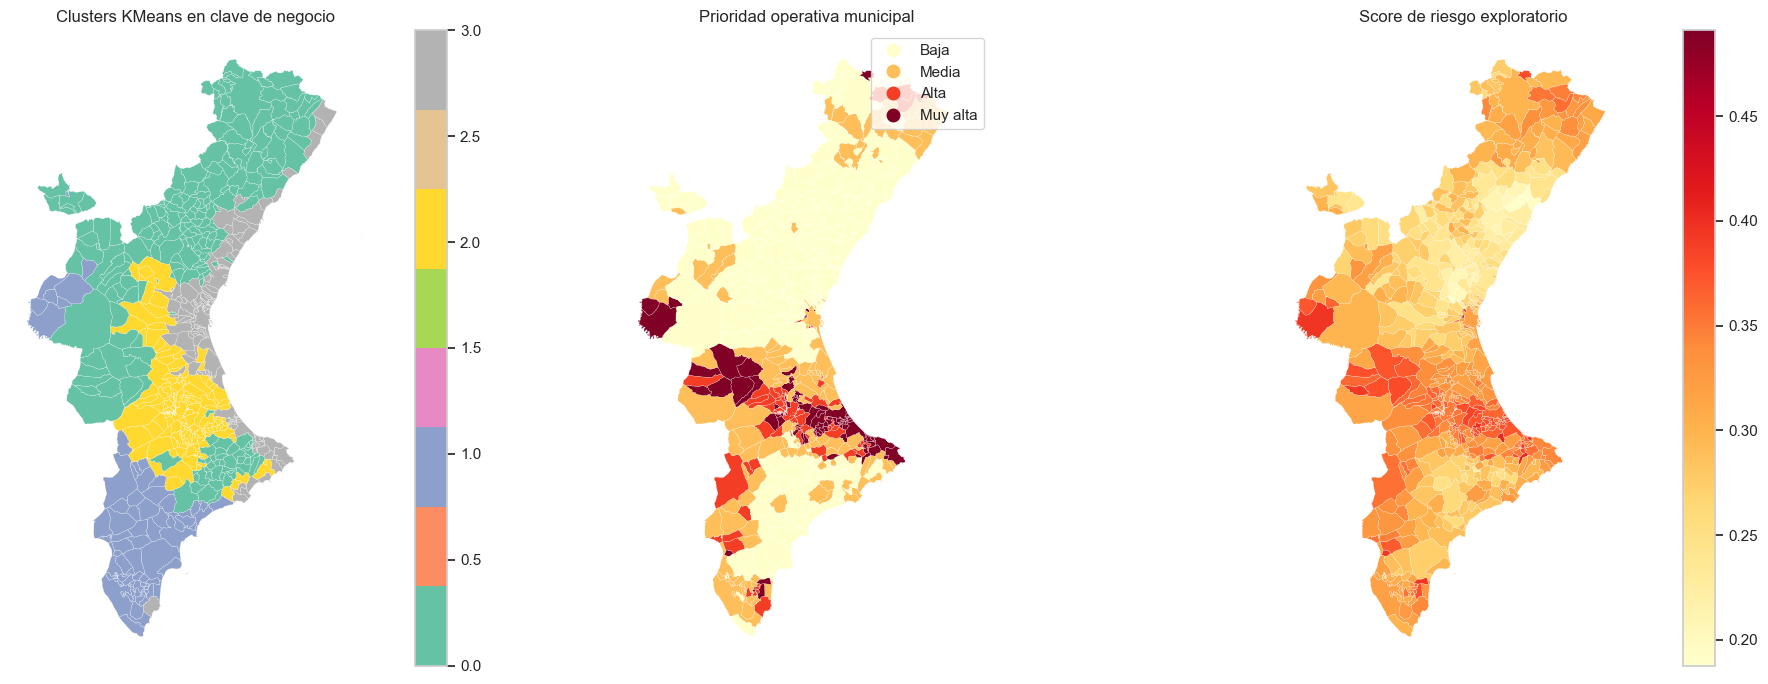

In [11]:
map_priority_order = ["Baja", "Media", "Alta", "Muy alta"]
gdf_business["prioridad_negocio"] = pd.Categorical(
    gdf_business["prioridad_negocio"],
    categories=map_priority_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

gdf_business.plot(
    column="cluster_kmeans",
    cmap="Set2",
    legend=True,
    ax=axes[0],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[0].set_title("Clusters KMeans en clave de negocio")
axes[0].axis("off")

gdf_business.plot(
    column="prioridad_negocio",
    cmap="YlOrRd",
    legend=True,
    ax=axes[1],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[1].set_title("Prioridad operativa municipal")
axes[1].axis("off")

gdf_business.plot(
    column=riesgo_col,
    cmap="YlOrRd",
    legend=True,
    ax=axes[2],
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)
axes[2].set_title("Score de riesgo exploratorio")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [12]:
priority_by_cluster = (
    df_seg.groupby(["cluster_kmeans", "prioridad_negocio"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=priority_order, fill_value=0)
)

display(priority_by_cluster)

prioridad_negocio,Muy alta,Alta,Media,Baja
cluster_kmeans,,,,
0,13,11,40,146
1,6,11,27,24
2,35,31,41,29
3,32,4,20,72


La representacion espacial permite comprobar que las prioridades no se distribuyen de forma aleatoria, sino que responden a combinaciones territoriales concretas de clima, vulnerabilidad y exposicion. Esta lectura resulta especialmente util para pasar de una lista de municipios a una interpretacion espacial mas cercana a decisiones de vigilancia, seguimiento o segmentacion de cartera.

Ademas, el cruce entre clusters y prioridad operativa ayuda a entender que una misma prioridad puede responder a logicas distintas: en algunos casos pesa mas la peligrosidad climatica, en otros la vulnerabilidad demografica o la exposicion urbana. Esta distincion es relevante porque sugiere que las posibles respuestas de negocio tampoco deberian ser identicas en todos los territorios.

La prueba con `DBSCAN` refuerza esta idea desde otro angulo: no todos los municipios encajan en agrupaciones densas, por lo que algunos territorios deben tratarse como casos singulares y no solo como miembros de un perfil medio.

## 5. Implicaciones para una aseguradora

A partir de los perfiles municipales, de los rankings y de la prioridad operativa construida en los bloques anteriores, es posible extraer una primera lectura orientada a negocio. Esta lectura no sustituye un modelo actuarial ni una politica tarifaria real, pero si permite plantear usos potenciales del analisis para prevencion, seguimiento territorial y segmentacion de cartera.

El interes principal de este bloque reside en traducir los resultados tecnicos a preguntas mas proximas a la decision: que territorios merecen mayor vigilancia, donde pueden concentrarse riesgos emergentes, y que perfiles municipales podrian justificar estrategias diferenciales de seguimiento o profundizacion analitica.

In [13]:
priority_business_table = (
    df_seg.groupby("prioridad_negocio", observed=False)
    .agg(
        municipios=("municipio", "count"),
        poblacion_total=("poblacion_total", "sum"),
        riesgo_medio=(riesgo_col, "mean"),
        peligro_medio=(peligro_col, "mean"),
        vulnerabilidad_media=(vulnerabilidad_col, "mean"),
        exposicion_media=(exposicion_col, "mean"),
        densidad_viviendas_media=("densidad_viviendas_catastro_km2", "mean"),
    )
    .round(3)
    .reindex(priority_order)
)

display(priority_business_table)

,municipios,poblacion_total,riesgo_medio,peligro_medio,vulnerabilidad_media,exposicion_media,densidad_viviendas_media
prioridad_negocio,,,,,,,
Muy alta,86,482233.0,0.376,0.469,0.423,0.073,791.906
Alta,57,349184.0,0.353,0.449,0.413,0.024,227.915
Media,128,1809000.0,0.322,0.396,0.400,0.022,208.691
Baja,271,2775426.0,0.266,0.299,0.371,0.024,213.062


Desde una perspectiva aseguradora, los resultados sugieren al menos cuatro lineas de utilidad potencial:

1. **Vigilancia territorial reforzada**: los municipios con prioridad `Muy alta` o `Alta` pueden considerarse candidatos para seguimiento especifico, revision periodica o analisis territorial adicional, especialmente cuando combinan peligro climatico elevado con vulnerabilidad social o exposicion construida.

2. **Prevencion y comunicacion segmentada**: los perfiles identificados permiten imaginar acciones preventivas diferenciadas. Por ejemplo, los clusters mas ligados a precipitacion extrema, calor o sequedad pueden asociarse a recomendaciones de prevencion climatica, mientras que los perfiles urbanos de alta exposicion pueden orientar acciones sobre continuidad operativa, mantenimiento preventivo o concentracion de capital expuesto.

3. **Segmentacion territorial de cartera**: aunque el trabajo no dispone de siniestros reales ni de primas, la tipologia municipal construida puede servir como capa auxiliar para segmentar territorios y priorizar donde conviene profundizar con informacion interna de exposicion, polizas o historicidad de eventos.

4. **Priorizacion de futuras integraciones de datos**: los municipios destacados por riesgo, peligro, vulnerabilidad o exposicion ofrecen una base razonable para decidir donde seria mas valioso incorporar nuevas fuentes, como siniestros reales, capitales asegurados, usos del inmueble, tipologia de poliza o detalle de cartera.

In [14]:
casos_tipo_negocio = (
    df_seg[
        [
            "municipio",
            "cluster_kmeans",
            "perfil_negocio_kmeans",
            "prioridad_negocio",
            riesgo_col,
            peligro_col,
            vulnerabilidad_col,
            exposicion_col,
            "densidad_poblacion",
            "densidad_viviendas_catastro_km2",
            "ratio_huella_edificada_pct",
            "mayores_65_pct",
            "renta_media_hogar",
        ]
    ]
    .sort_values(["prioridad_negocio", riesgo_col], ascending=[True, False])
    .groupby("perfil_negocio_kmeans")
    .head(2)
)

display(casos_tipo_negocio)

,municipio,cluster_kmeans,perfil_negocio_kmeans,prioridad_negocio,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,densidad_poblacion,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,mayores_65_pct,renta_media_hogar
92,Benetússer,3,Exposicion urbana alta y baja altitud,Muy alta,0.490856,0.347842,0.625274,0.646767,21451.10,9253.94,51.6428,19.36,32367.0
215,Emperador,3,Exposicion urbana alta y baja altitud,Muy alta,0.487039,0.345037,0.550293,0.747165,24305.56,10763.89,53.6153,12.15,39021.0
507,l'Atzúbia,2,Peligro climatico alto con exposicion moderada,Muy alta,0.406311,0.519953,0.483333,0.006673,40.12,40.40,0.5672,35.94,30891.0
21,Alcalalí,0,Interior envejecido y baja exposicion construida,Muy alta,0.404743,0.474477,0.550479,0.011805,99.19,73.77,1.0291,40.85,27781.0
100,Benicolet,2,Peligro climatico alto con exposicion moderada,Muy alta,0.401123,0.523869,0.459171,0.007183,53.82,34.68,0.7769,31.98,29760.0
456,Venta del Moro,1,Calor y sequedad elevados con vulnerabilidad m...,Muy alta,0.395733,0.463267,0.546350,0.000975,4.20,5.65,0.1245,35.93,22952.0
384,San Fulgencio,1,Calor y sequedad elevados con vulnerabilidad m...,Muy alta,0.393870,0.399722,0.605117,0.062369,471.80,504.89,4.6938,42.84,23694.0
485,Zarra,0,Interior envejecido y baja exposicion construida,Muy alta,0.391445,0.429470,0.588241,0.001189,7.52,6.20,0.1495,42.26,24395.0


La tabla de casos tipo ayuda a aterrizar el analisis en ejemplos concretos. En lugar de quedarse en clusters abstractos, permite visualizar municipios que representan perfiles distintos de negocio: territorios con mayor peligro climatico, municipios expuestos por densidad construida, zonas interiores envejecidas o combinaciones de calor, sequedad y vulnerabilidad.

Esta lectura no basta por si sola para definir acciones comerciales o tarifarias, pero si aporta una base argumental util para justificar donde podria concentrarse primero un esfuerzo adicional de analisis, prevencion o enriquecimiento de informacion interna.

## 6. Limitaciones y continuidad del analisis de negocio

Aunque el analisis desarrollado en este cuaderno permite traducir los resultados tecnicos a una lectura aplicada para una aseguradora, conviene subrayar varias limitaciones. En primer lugar, el trabajo no dispone de datos reales de siniestralidad, primas, exposicion asegurada ni composicion efectiva de cartera, por lo que las conclusiones no pueden interpretarse como una politica tarifaria ni como una estimacion real de impacto economico.

En segundo lugar, la resolucion espacial del bloque climatico sigue condicionada por la malla de `ERA5-Land`, lo que implica que varios municipios comparten una misma representacion climatica. Esto reduce el detalle territorial fino y aconseja interpretar los resultados como una aproximacion municipal robusta, pero no como una medicion exacta del riesgo local.

En tercer lugar, aunque Catastro aporta una mejora clara como aproximacion a exposicion fisica, sigue siendo una fuente abierta agregada. No sustituye informacion aseguradora interna sobre capitales asegurados, usos del inmueble, tipos de poliza, medidas de proteccion, antiguedad real del riesgo asegurado o historial de siniestros.

Tambien debe recordarse que `DBSCAN` se utiliza solo como lectura auxiliar. Su sensibilidad a parametros y la existencia de municipios clasificados como ruido hacen que sea util para detectar posibles hotspots o casos singulares, pero no para definir por si solo una segmentacion de negocio.

Precisamente por ello, la continuidad natural del trabajo consistiria en enriquecer esta base con informacion adicional. Entre las ampliaciones mas valiosas se encuentran la incorporacion de siniestros reales, datos internos de cartera, capitales asegurados, detalle de usos constructivos, validaciones climaticas adicionales y, en una fase mas avanzada, fuentes o modelos climaticos de mayor resolucion. En ese escenario, la tipologia municipal construida aqui podria servir como capa previa de segmentacion sobre la que apoyar analisis aseguradores mas proximos a la decision real.

## 7. Conclusiones del analisis de negocio

El Analisis de Negocio realizado en este cuaderno permite transformar la base municipal segmentada en una lectura aplicada del territorio desde la perspectiva aseguradora. A partir de los clusters, de los indicadores climaticos ampliados, de la exposicion fisica y de la prioridad operativa construida, se han identificado perfiles municipales diferenciados que combinan de forma distinta peligro climatico, exposicion y vulnerabilidad.

El principal valor de esta fase no reside en ofrecer una respuesta actuarial cerrada, sino en demostrar que la informacion abierta tratada en las fases anteriores puede organizarse de forma util para priorizar territorios, orientar vigilancia, plantear estrategias preventivas y decidir donde tendria mas sentido profundizar con informacion interna de negocio.

La incorporacion de contrastes como `Agglomerative Clustering` y `DBSCAN` refuerza la lectura metodologica: el primero aporta estabilidad comparativa y el segundo ayuda a detectar densidades espaciales o municipios singulares, mientras que `KMeans` queda como salida principal para negocio.

En conjunto, el trabajo deja preparada una base metodologica coherente para una continuidad futura mas cercana a uso asegurador real. Incluso sin datos internos de siniestros, el proyecto ya permite pasar de una lectura puramente climatica a una interpretacion territorial estructurada, conectando Ingenieria del Dato, Analisis del Dato, Modelado y Analisis de Negocio dentro de una misma narrativa de TFG.